# torch classification 

In [1]:
%pip install scikit-learn seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
%matplotlib inline

In [3]:
# 사이킷런(sklearn)이 제공하는 붓꽃(Iris) 데이터셋을 불러온다.
# 특징(feature) 4개와 품종(label) 3개로 구성된 대표적인 분류용 데이터.
data = load_iris()

In [4]:
print(type(data))

<class 'sklearn.utils._bunch.Bunch'>


In [5]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [6]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [7]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target

In [8]:
print(data.target_names)

['setosa' 'versicolor' 'virginica']


In [9]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [11]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [13]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


<Axes: >

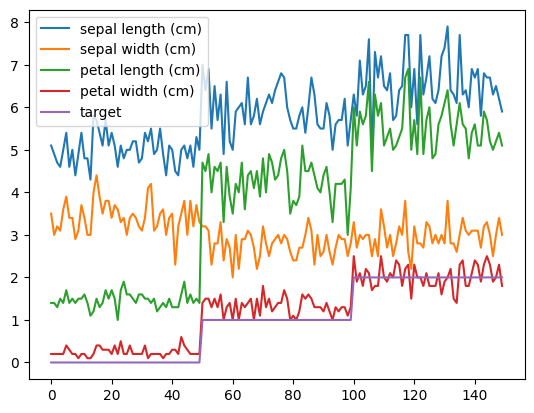

In [14]:
df.plot()

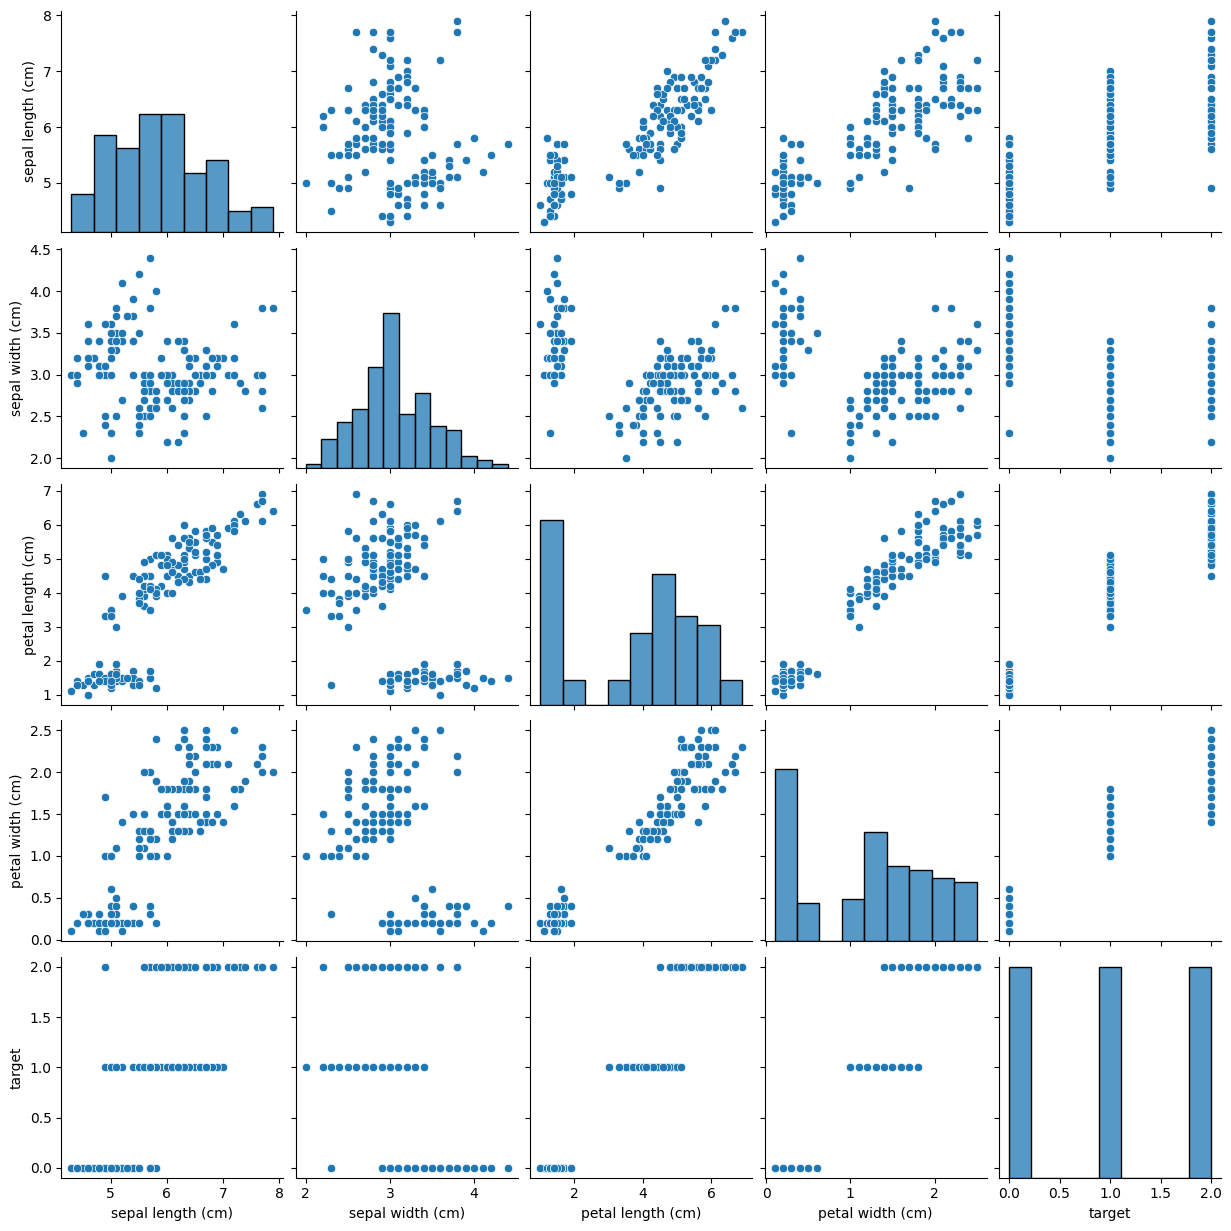

In [15]:
sns.pairplot(df)

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils

In [17]:
class IrisModel(nn.Module):
    def __init__(self, input_size, output_size):
        # nn.Module 초기화
        super(IrisModel, self).__init__()
        
        # 간단한 분류용 신경망 구조 정의
        # 입력 → Linear(입력층) → ReLU 활성화 → Linear(출력층)
        self.model = nn.Sequential(
            nn.Linear(input_size, 16),  # 입력 특성에서 16차원으로 변환
            nn.ReLU(),                  # 비선형 활성화 함수
            nn.Linear(16, output_size)  # 클래스 개수만큼 출력
        )
        
    def forward(self, x):
        # 순전파: 정의한 모델 구조를 그대로 통과시킴
        output = self.model(x)

        # softmax로 각 클래스별 확률값 계산 (dim=1: 각 데이터의 클래스를 기준으로)
        result = F.softmax(output, dim=1)

        # no_grad: 학습과 무관하게 연산 그래프를 만들지 않음
        # argmax로 가장 확률이 큰 클래스 인덱스를 예측값으로 선택
        with torch.no_grad():
            value = torch.argmax(result, dim=1)

        # output: raw logits (softmax 전 값)
        # value: 예측된 클래스 번호
        return output, value

In [18]:
X = torch.Tensor(data.data)
y = torch.LongTensor(data.target)

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # train과 test를 8:2로 분할

In [20]:
model = IrisModel(4, 3) # 입력은 4, 출력은 3종류의 확률

In [21]:
print(X_train.shape)

torch.Size([120, 4])


In [22]:
print(y_train.shape) 

torch.Size([120])


In [23]:
print(X_train[0].shape)

torch.Size([4])


In [24]:
print(torch.unsqueeze(X_train[0], dim=0).shape)

torch.Size([1, 4])


In [25]:
with torch.no_grad():
    y, _ = model(torch.unsqueeze(X_train[0], dim=0))
    print(y)
    print(F.softmax(y))
    print(F.softmax(y).sum())
    print(np.argmax(y), y_train[0])

tensor([[-0.1751,  0.3869, -0.6711]])
tensor([[0.2973, 0.5216, 0.1811]])
tensor(1.0000)
tensor(1) tensor(0)


C:\Users\Shiverlog\AppData\Local\Temp\ipykernel_8052\113627717.py:4: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.softmax(y))
C:\Users\Shiverlog\AppData\Local\Temp\ipykernel_8052\113627717.py:5: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.softmax(y).sum())


In [26]:
print(y.shape)

torch.Size([1, 3])


In [27]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [28]:
print(model)

IrisModel(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)


In [29]:
# 입력 특성 4개, 출력 클래스 3개를 가지는 모델 생성
model = IrisModel(4, 3)

# Adam 옵티마이저 설정 (학습률 0.004)
optimizer = torch.optim.Adam(model.parameters(), lr=0.004)

# 다중 클래스 분류에 적합한 손실 함수: CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# 전체 학습 반복 횟수
n_epochs = 10000

for epoch in range(n_epochs):
    # 모델의 forward 호출 → y는 raw logits, _는 argmax 결과(사용하지 않음)
    y, _ = model(X_train)

    # 정답 레이블
    target = y_train

    # 손실 계산 (CrossEntropyLoss는 자동으로 softmax 포함)
    loss = criterion(y, target).sum()

    # 기존에 쌓인 gradient 초기화
    optimizer.zero_grad()

    # 역전파로 gradient 계산
    loss.backward()

    # 계산된 gradient로 모델 가중치 업데이트
    optimizer.step()

    # 1000회마다 현재 손실 출력
    if epoch % 1000 == 0:
        print('epoch {}th loss: {}'.format(epoch, loss.data))


epoch 0th loss: 1.0331041812896729


epoch 1000th loss: 0.05295124277472496
epoch 2000th loss: 0.04321343079209328
epoch 3000th loss: 0.038040049374103546
epoch 4000th loss: 0.035398516803979874
epoch 5000th loss: 0.034285418689250946
epoch 6000th loss: 0.03387300297617912
epoch 7000th loss: 0.033746540546417236
epoch 8000th loss: 0.033717505633831024
epoch 9000th loss: 0.03371259197592735


In [30]:
n = 100
with torch.no_grad():
    y, _ = model(torch.unsqueeze(X_train[n], dim=0))
    print(y)
    print(y.sum())
    print(np.argmax(y), y_train[n])

tensor([[-10.3128,  -3.8545,  12.7852]])
tensor(-1.3821)
tensor(2) tensor(2)


In [ ]:
# 입력 4개, 출력 클래스 3개인 Iris 모델 생성
model = IrisModel(4, 3)

# Adam 옵티마이저 설정 (학습률 0.004)
optimizer = torch.optim.Adam(model.parameters(), lr=0.004)

# 다중 분류 문제용 손실 함수
criterion = nn.CrossEntropyLoss()

# 학습 반복 횟수
n_epochs = 10000

# 학습 손실 및 테스트 손실 기록용 리스트
list_training_loss = []
list_test_loss = []

for epoch in range(n_epochs):

    # 모델을 학습 모드로 전환 (Dropout, BatchNorm 등 활성화)
    model.train()

    # 학습 데이터로 forward 수행
    y, _ = model(X_train)
    target = y_train

    # 손실 계산 (CrossEntropyLoss는 softmax 포함)
    loss = criterion(y, target).sum()

    # 기존 gradient 초기화
    optimizer.zero_grad()

    # 손실로부터 gradient 계산 (역전파)
    loss.backward()

    # 옵티마이저가 파라미터 업데이트
    optimizer.step()

    # 1000회마다 학습·테스트 손실 측정
    if epoch % 1000 == 0:

        # 모델을 평가 모드로 전환 (Dropout, BatchNorm 비활성화)
        model.eval()

        # 테스트 데이터로 예측
        y_pred, _ = model(X_test)

        # 테스트 데이터 손실 계산
        test_loss = criterion(y_pred, y_test).sum()

        # 현재 학습 손실 / 테스트 손실 출력
        print('epoch {}th training loss: {} test loss: {}'.format(
            epoch, loss.data, test_loss.data))

        # 손실 값 기록
        list_training_loss.append(loss.data)
        list_test_loss.append(test_loss.data)


epoch 0th training loss: 1.549498438835144 test loss: 1.4325493574142456
epoch 1000th training loss: 0.05476177856326103 test loss: 0.018114348873496056
epoch 2000th training loss: 0.04464327543973923 test loss: 0.036514703184366226
epoch 3000th training loss: 0.03934614732861519 test loss: 0.13660196959972382
epoch 4000th training loss: 0.034910812973976135 test loss: 0.2848406136035919
epoch 5000th training loss: 0.03155741095542908 test loss: 0.4346481263637543
epoch 6000th training loss: 0.03022054210305214 test loss: 0.5439755320549011
epoch 7000th training loss: 0.030178075656294823 test loss: 0.6531094312667847
epoch 8000th training loss: 0.029182545840740204 test loss: 0.7057815194129944
epoch 9000th training loss: 0.0290377214550972 test loss: 0.7589565515518188


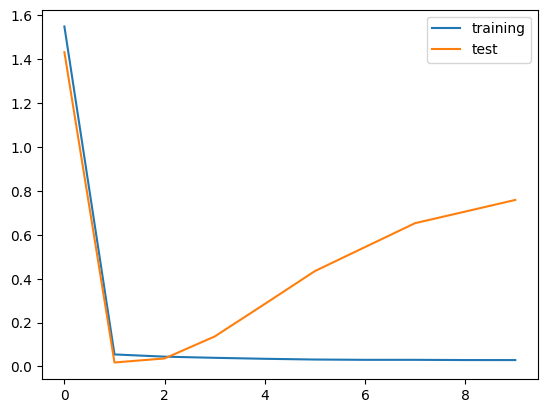

In [32]:
import matplotlib.pyplot as plt

plt.plot(list_training_loss, label='training')
plt.plot(list_test_loss, label='test')
plt.legend()
plt.show()

In [ ]:
# sklearn의 accuracy_score: 예측값과 정답을 비교해 정확도를 계산하는 함수
from sklearn.metrics import accuracy_score

# 평가 단계에서는 gradient 계산이 필요 없으므로 no_grad() 사용
with torch.no_grad():

    # 모델에 테스트 데이터를 넣어 예측 수행
    # 첫 번째 값은 logits(사용하지 않음), 두 번째 y_pred는 argmax된 클래스 인덱스
    _, y_pred = model(X_test)

    # 정답(y_test)과 예측(y_pred)을 비교하여 정확도 계산
    score = accuracy_score(y_test, y_pred)

    # 최종 정확도 출력
    print(score)

0.9333333333333333
